#**Analisis Data Time Series untuk Prediksi Jumlah Sampah di Kota Bandung**

Latar Belakang
```
Pengelolaan sampah merupakan salah satu tantangan utama di perkotaan, termasuk di Kota Bandung. Jumlah sampah yang dihasilkan
cenderung berubah dari waktu ke waktu seiring dengan aktivitas masyarakat. Oleh karena itu, diperlukan analisis untuk memahami
pola dan tren jumlah sampah.
```
Tujuan Analisis
```
Analisis ini bertujuan untuk:
- Mengidentifikasi tren jumlah sampah dari waktu ke waktu
- Mengetahui pola perubahan sampah berdasarkan bulan dan tahun
- Melakukan prediksi (forecasting) jumlah sampah pada periode berikutnya
```

Metode yang Digunakan
```
Pendekatan yang digunakan adalah analisis time series dengan:
- Eksplorasi data (EDA)
- Analisis tren dan pola musiman
- Prediksi seperti moving average dan/atau ARIMA
```

Sumber Data
```
Data yang digunakan berasal dari Open Data Kota Bandung, yang berisi informasi jumlah capaian penanganan sampah dalam satuan
ton pada periode 2017–2024.

Library


In [ ]:
# @title
# Basic libraries
import warnings
import itertools

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
warnings.filterwarnings("ignore")

In [ ]:
# @title
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRDX1_R6OCNnA1TUuc96agHI7aIbh9RNJ7817DR9aBwW08n5dXYpztNSv_2WmeIsw/pub?output=xlsx'
df = pd.read_excel(url)

##**1. Load Data**


In [ ]:
# @title
df.head()

,id,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bulan,jumlah_sampah,satuan,tahun
0,1,32,JAWA BARAT,3273,KOTA BANDUNG,JANUARI,28695.810,TON,2017
1,2,32,JAWA BARAT,3273,KOTA BANDUNG,FEBRUARI,25235.730,TON,2017
2,3,32,JAWA BARAT,3273,KOTA BANDUNG,MARET,27581.190,TON,2017
3,4,32,JAWA BARAT,3273,KOTA BANDUNG,APRIL,29664.735,TON,2017
4,5,32,JAWA BARAT,3273,KOTA BANDUNG,MEI,34637.092,TON,2017


Pada tahap ini, dataset berhasil dimuat ke dalam Python. Data terdiri dari sejumlah baris dan kolom yang memuat informasi jumlah sampah Kota Bandung berdasarkan periode bulan dan tahun. Tampilan lima data awal digunakan untuk memastikan bahwa data telah terbaca dengan benar sebelum dilakukan tahap pemahaman dan preprocessing data.

In [ ]:
# @title
print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (96, 9)


In [ ]:
# @title
print("Nama kolom:")
print(df.columns.tolist())

Nama kolom:
['id', 'kode_provinsi', 'nama_provinsi', 'bps_kode_kabupaten_kota', 'bps_nama_kabupaten_kota', 'bulan', 'jumlah_sampah', 'satuan', 'tahun']


##**2. Understanding Data**
```
- Mengetahui ukuran dan struktur dataset.
- Memastikan tipe data setiap kolom sudah sesuai.
- Melihat gambaran awal variabel `jumlah_sampah`.
- Mengecek apakah terdapat missing value.
- Mengecek apakah terdapat data duplikat.
- Memastikan data hanya memuat Kota Bandung.
- Memastikan satuan data yang digunakan adalah ton.
- Memastikan setiap tahun memiliki 12 data bulanan.

In [ ]:
# @title
df[['jumlah_sampah']].describe().T

,count,mean,std,min,25%,50%,75%,max
jumlah_sampah,96.0,36851.510729,4969.481349,22919.4,33850.621,38395.112,40671.701,43576.848


In [ ]:
# @title
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       96 non-null     int64  
 1   kode_provinsi            96 non-null     int64  
 2   nama_provinsi            96 non-null     object 
 3   bps_kode_kabupaten_kota  96 non-null     int64  
 4   bps_nama_kabupaten_kota  96 non-null     object 
 5   bulan                    96 non-null     object 
 6   jumlah_sampah            96 non-null     float64
 7   satuan                   96 non-null     object 
 8   tahun                    96 non-null     int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 6.9+ KB


In [ ]:
# @title
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Duplicates Values: {df.duplicated().sum()}')

Missing Values: 0
Duplicates Values: 0


In [ ]:
# @title
print("Jumlah data per tahun:")
display(df['tahun'].value_counts().sort_index())

Jumlah data per tahun:


,count
tahun,
2017,12
2018,12
2019,12
2020,12
2021,12
2022,12
2023,12
2024,12


In [ ]:
# @title
print("Wilayah:", df['bps_nama_kabupaten_kota'].unique())
print("Satuan:", df['satuan'].unique())

Wilayah: ['KOTA BANDUNG']
Satuan: ['TON']


Hasil Temuan
```
- Dataset terdiri dari 96 observasi dan 9 kolom.
- Variabel utama: `jumlah_sampah`.
- Satuan data: ton.
- Wilayah data: Kota Bandung.
- Periode data: 2017–2024.
- Setiap tahun memiliki 12 data bulanan.
- Tidak terdapat missing value.
- Tidak terdapat data duplikat.

##**3. Preprocessing Data Time Series**
```
- Pembentukan kolom tanggal: agar data bulan dan tahun berubah menjadi format waktu yang bisa dibaca Python.
- Penentuan index time series: agar data dapat dianalisis berdasarkan urutan waktu.
- Pemeriksaan missing value dan duplikasi: agar data yang dipakai bersih dan tidak bias.
- Pemeriksaan kelengkapan periode bulanan: agar tidak ada bulan yang hilang dalam rentang 2017–2024.

In [ ]:
# @title
# Copy data agar data asli tetap aman
df_ts = df.copy()

###3.1 Pembentukan Kolom Tanggal

In [ ]:
# @title
bulan_map = {
    'JANUARI': 1,
    'FEBRUARI': 2,
    'MARET': 3,
    'APRIL': 4,
    'MEI': 5,
    'JUNI': 6,
    'JULI': 7,
    'AGUSTUS': 8,
    'SEPTEMBER': 9,
    'OKTOBER': 10,
    'NOVEMBER': 11,
    'DESEMBER': 12
}

df_ts['bulan_num'] = df_ts['bulan'].str.upper().map(bulan_map)

df_ts['tanggal'] = pd.to_datetime({
    'year': df_ts['tahun'],
    'month': df_ts['bulan_num'],
    'day': 1
})

display(df_ts[['tahun', 'bulan', 'bulan_num', 'tanggal', 'jumlah_sampah']].head())

,tahun,bulan,bulan_num,tanggal,jumlah_sampah
0,2017,JANUARI,1,2017-01-01,28695.810
1,2017,FEBRUARI,2,2017-02-01,25235.730
2,2017,MARET,3,2017-03-01,27581.190
3,2017,APRIL,4,2017-04-01,29664.735
4,2017,MEI,5,2017-05-01,34637.092


###3.2 Penentuan Index Time Series

In [ ]:
# @title
df_ts = df_ts.sort_values('tanggal')
df_ts = df_ts.set_index('tanggal')

# Membentuk series utama untuk analisis time series
ts = df_ts['jumlah_sampah'].asfreq('MS')

print("Tanggal awal:", ts.index.min())
print("Tanggal akhir:", ts.index.max())
print("Jumlah observasi time series:", len(ts))

display(ts.head())
display(ts.tail())

Tanggal awal: 2017-01-01 00:00:00
Tanggal akhir: 2024-12-01 00:00:00
Jumlah observasi time series: 96


,jumlah_sampah
tanggal,
2017-01-01,28695.810
2017-02-01,25235.730
2017-03-01,27581.190
2017-04-01,29664.735
2017-05-01,34637.092


,jumlah_sampah
tanggal,
2024-08-01,30503.984
2024-09-01,29819.496
2024-10-01,31004.736
2024-11-01,26452.748
2024-12-01,24220.784


###3.3 Pemeriksaan Missing Value dan Duplikasi

In [ ]:
# @title
print("Missing value setelah preprocessing:")
print(df_ts.isnull().sum())

print("\nJumlah data duplikat:")
print(df_ts.duplicated().sum())

print("\nJumlah duplikasi index tanggal:")
print(df_ts.index.duplicated().sum())

Missing value setelah preprocessing:
id                         0
kode_provinsi              0
nama_provinsi              0
bps_kode_kabupaten_kota    0
bps_nama_kabupaten_kota    0
bulan                      0
jumlah_sampah              0
satuan                     0
tahun                      0
bulan_num                  0
dtype: int64

Jumlah data duplikat:
0

Jumlah duplikasi index tanggal:
0


###3.4 Pemeriksaan Kelengkapan Periode Bulanan

In [ ]:
# @title
periode_lengkap = pd.date_range(
    start=ts.index.min(),
    end=ts.index.max(),
    freq='MS'
)

periode_hilang = periode_lengkap.difference(ts.index)

print("Jumlah periode seharusnya:", len(periode_lengkap))
print("Jumlah periode aktual:", len(ts))
print("Jumlah periode hilang:", len(periode_hilang))

if len(periode_hilang) == 0:
    print("Tidak ada periode bulanan yang hilang.")
else:
    print("Periode yang hilang:")
    print(periode_hilang)

Jumlah periode seharusnya: 96
Jumlah periode aktual: 96
Jumlah periode hilang: 0
Tidak ada periode bulanan yang hilang.


Hasil Temuan
```
- Kolom `tanggal` berhasil dibentuk dari kolom `tahun` dan `bulan`.
- Data sudah diurutkan berdasarkan waktu.
- Kolom `tanggal` digunakan sebagai index time series.
- Periode data dimulai dari Januari 2017 sampai Desember 2024.
- Jumlah observasi time series sebanyak 96 data bulanan.
- Tidak terdapat missing value setelah preprocessing.
- Tidak terdapat data duplikat.
- Tidak terdapat duplikasi index tanggal.
- Tidak ada periode bulanan yang hilang.

##**4. Exploratory Data Analysis**
```
- Melihat pola awal jumlah sampah dari waktu ke waktu.
- Mengidentifikasi tren kenaikan atau penurunan.
- Melihat fluktuasi data bulanan.
- Mengecek kemungkinan pola musiman.
- Menjadi dasar sebelum membangun model forecasting.

###4.1 Time Series Plot
```
Visualisasi ini dibuat untuk melihat pola jumlah sampah Kota Bandung dari waktu ke waktu, apakah cenderung naik, turun, stabil,
atau mengalami perubahan tertentu.

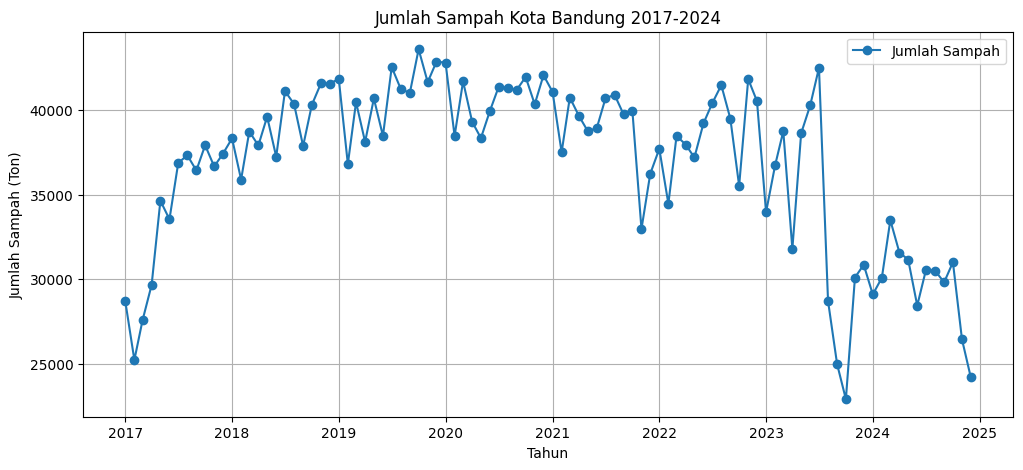

In [ ]:
# @title
plt.figure(figsize=(12,5))
plt.plot(ts, marker='o', linewidth=1.5, label='Jumlah Sampah')

plt.title('Jumlah Sampah Kota Bandung 2017-2024')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Sampah (Ton)')
plt.legend()
plt.grid(True)
plt.show()

Hasil Temuan
```
- Jumlah sampah meningkat dari 2017 hingga sekitar 2019–2020.
- Setelah 2020, pola mulai cenderung menurun.
- Data menunjukkan fluktuasi bulanan yang cukup besar.
- Penurunan tajam terlihat pada periode 2023–2024.
- Secara visual, data menunjukkan adanya perubahan tren.

###4.2 Moving Average
```
Moving average digunakan untuk memperhalus naik turunnya data bulanan, sehingga tren jangka panjang jumlah sampah lebih mudah
terlihat.

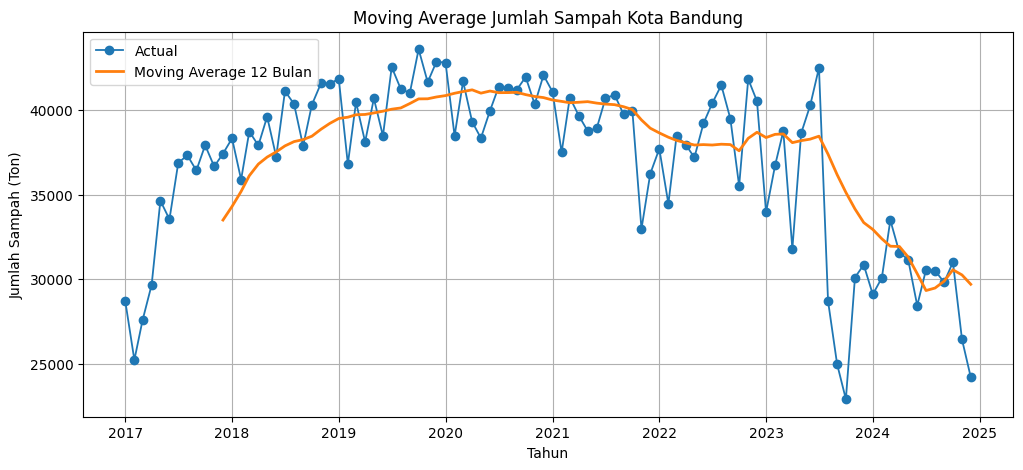

In [ ]:
# @title
rolling_mean = ts.rolling(window=12).mean()

plt.figure(figsize=(12,5))
plt.plot(ts, marker='o', linewidth=1.3, label='Actual')
plt.plot(rolling_mean, linewidth=2, label='Moving Average 12 Bulan')

plt.title('Moving Average Jumlah Sampah Kota Bandung')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Sampah (Ton)')
plt.legend()
plt.grid(True)
plt.show()

Hasil Temuan
```
- Garis moving average naik dari 2017 sampai sekitar 2020.
- Pada sekitar 2020–2021, tren mulai terlihat stabil.
- Setelah 2021, garis moving average mulai menurun.
- Penurunan paling jelas terlihat pada 2023–2024.
- Data aktual lebih naik-turun, sedangkan moving average lebih halus.

###4.3 Boxplot per Tahun
```
Boxplot per tahun dibuat untuk membandingkan sebaran jumlah sampah tiap tahun, termasuk median, variasi data, dan kemungkinan
nilai yang cukup ekstrem.

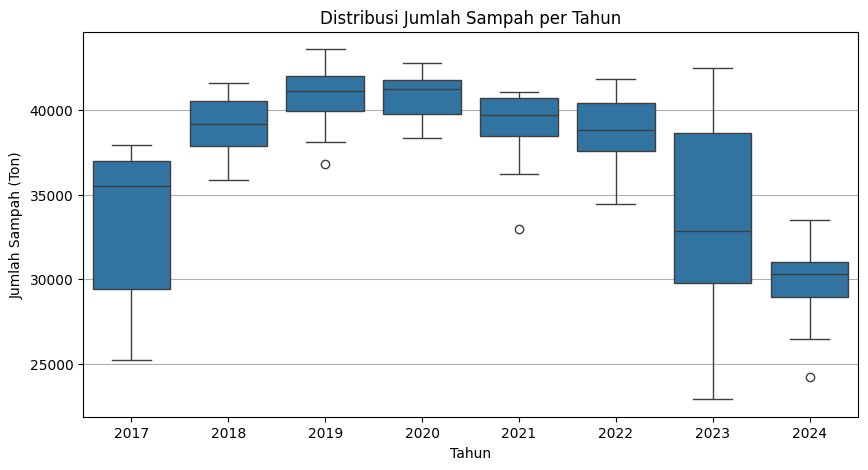

In [ ]:
# @title
df_box = df_ts.copy()
df_box['tahun_plot'] = df_box.index.year

plt.figure(figsize=(10,5))
sns.boxplot(x='tahun_plot', y='jumlah_sampah', data=df_box)

plt.title('Distribusi Jumlah Sampah per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Sampah (Ton)')
plt.grid(axis='y')
plt.show()

Hasil Temuan
```
- Median jumlah sampah tertinggi terlihat pada 2019–2020.
- Tahun 2017 memiliki sebaran data yang cukup lebar.
- Tahun 2023 memiliki variasi data paling besar.
- Tahun 2024 menunjukkan jumlah sampah yang lebih rendah dibanding tahun-tahun sebelumnya.
- Terdapat beberapa nilai ekstrem pada 2019, 2021, dan 2024.

###4.4 Rata-rata Jumlah Sampah per Tahun
```
Grafik ini dibuat untuk melihat rata-rata jumlah sampah setiap tahun, sehingga terlihat tahun mana yang cenderung tinggi atau
rendah.

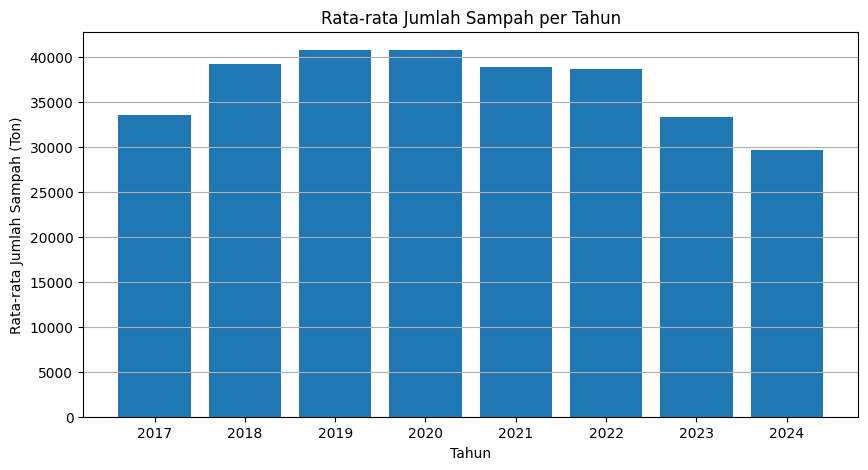

,jumlah_sampah
tanggal,
2017,33494.458083
2018,39196.471833
2019,40758.869667
2020,40721.778917
2021,38916.927333
2022,38675.674333
2023,33345.545333
2024,29702.360333


In [ ]:
# @title
rata_tahun = df_ts.groupby(df_ts.index.year)['jumlah_sampah'].mean()

plt.figure(figsize=(10,5))
plt.bar(rata_tahun.index, rata_tahun.values)

plt.title('Rata-rata Jumlah Sampah per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Jumlah Sampah (Ton)')
plt.grid(axis='y')
plt.show()

display(rata_tahun)

Hasil Temuan
```
- Rata-rata jumlah sampah tertinggi terjadi pada 2019 dan 2020.
- Tahun 2017 memiliki rata-rata lebih rendah dibanding 2018–2022.
- Setelah 2020, rata-rata jumlah sampah mulai menurun.
- Penurunan cukup jelas terlihat pada 2023 dan 2024.
- Tahun 2024 menjadi tahun dengan rata-rata jumlah sampah paling rendah.

###4.5 Rata-rata per Bulan
```
Grafik ini dibuat untuk melihat bulan mana yang memiliki rata-rata jumlah sampah lebih tinggi atau lebih rendah.

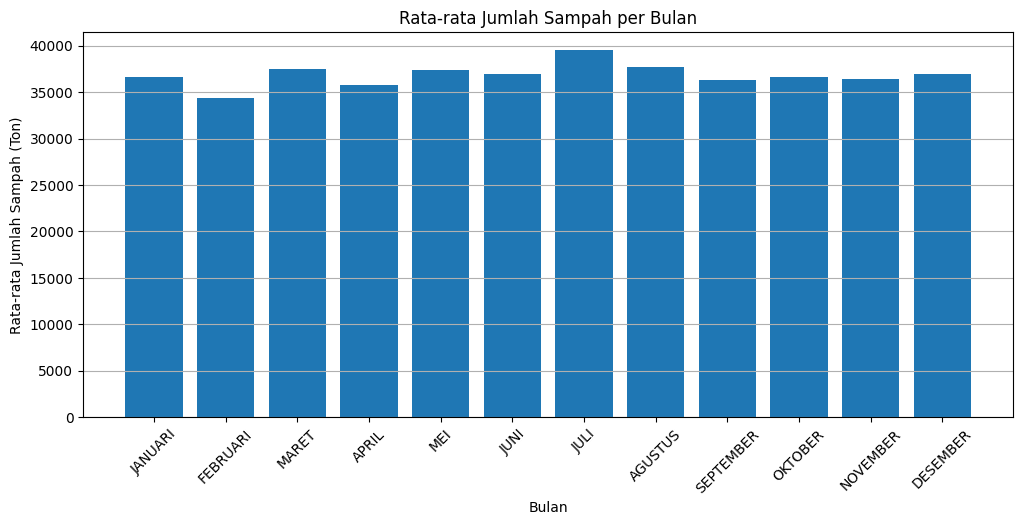

,jumlah_sampah
bulan,
JANUARI,36679.507750
FEBRUARI,34392.323250
MARET,37481.351750
APRIL,35741.047375
MEI,37368.261000
JUNI,36998.980625
JULI,39496.040500
AGUSTUS,37718.899750
SEPTEMBER,36310.061750


In [ ]:
# @title
urutan_bulan = [
    'JANUARI', 'FEBRUARI', 'MARET', 'APRIL', 'MEI', 'JUNI',
    'JULI', 'AGUSTUS', 'SEPTEMBER', 'OKTOBER', 'NOVEMBER', 'DESEMBER'
]

rata_bulan = df_ts.groupby('bulan')['jumlah_sampah'].mean().reindex(urutan_bulan)

plt.figure(figsize=(12,5))
plt.bar(rata_bulan.index, rata_bulan.values)

plt.title('Rata-rata Jumlah Sampah per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Jumlah Sampah (Ton)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

display(rata_bulan)

Hasil Temuan
```
- Rata-rata jumlah sampah bulanan relatif tidak berbeda jauh.
- Bulan Juli memiliki rata-rata jumlah sampah paling tinggi.
- Bulan Februari memiliki rata-rata jumlah sampah paling rendah.
- Perbedaan antar bulan ada, tetapi tidak terlalu ekstrem.
- Pola ini menunjukkan adanya indikasi musiman, tetapi tidak terlalu kuat.

###4.6 Heatmap Tahun-Bulan
```
Heatmap dibuat untuk melihat pola jumlah sampah berdasarkan kombinasi tahun dan bulan.

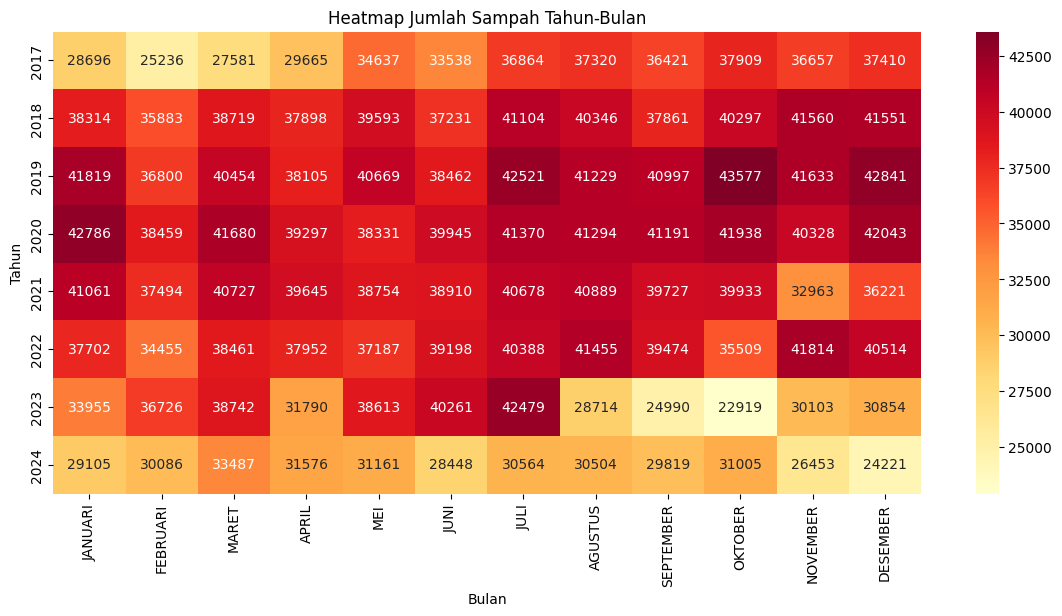

In [ ]:
# @title
df_heatmap = df_ts.copy()
df_heatmap['tahun_plot'] = df_heatmap.index.year
df_heatmap['bulan_plot'] = df_heatmap['bulan']

pivot_heatmap = df_heatmap.pivot_table(
    values='jumlah_sampah',
    index='tahun_plot',
    columns='bulan_plot',
    aggfunc='mean'
)

pivot_heatmap = pivot_heatmap[urutan_bulan]

plt.figure(figsize=(14,6))
sns.heatmap(pivot_heatmap, annot=True, fmt='.0f', cmap='YlOrRd')

plt.title('Heatmap Jumlah Sampah Tahun-Bulan')
plt.xlabel('Bulan')
plt.ylabel('Tahun')
plt.show()

Hasil Temuan
```
- Warna lebih gelap banyak terlihat pada periode 2019–2022.
- Periode 2019–2020 menunjukkan jumlah sampah yang relatif tinggi.
- Tahun 2023 mulai menunjukkan penurunan pada beberapa bulan.
- Tahun 2024 terlihat lebih rendah hampir di semua bulan.
- Nilai rendah paling jelas terlihat pada akhir 2024.
- Heatmap memperkuat temuan bahwa terjadi perubahan pola pada 2023–2024.

###4.7 Distribusi Jumlah Sampah
```
Distribusi jumlah sampah dibuat untuk melihat sebaran nilai data, apakah cenderung normal, miring, atau memiliki nilai ekstrem.

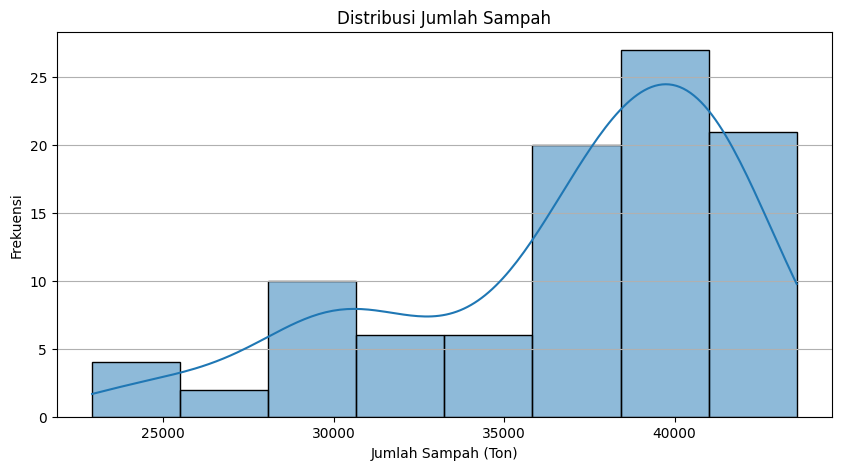

In [ ]:
# @title
plt.figure(figsize=(10,5))
sns.histplot(df_ts['jumlah_sampah'], kde=True)

plt.title('Distribusi Jumlah Sampah')
plt.xlabel('Jumlah Sampah (Ton)')
plt.ylabel('Frekuensi')
plt.grid(axis='y')
plt.show()

Hasil Temuan
```
- Sebagian besar data berada pada rentang sekitar 36.000–42.000 ton.
- Data dengan jumlah sampah rendah berada sekitar 23.000–31.000 ton.
- Distribusi tidak sepenuhnya simetris.
- Terdapat beberapa nilai rendah yang membuat distribusi agak melebar ke kiri.
- Hal ini menunjukkan adanya periode dengan penurunan jumlah sampah yang cukup besar.

###4.8 Seasonal Decomposition
```
Seasonal decomposition dibuat untuk melihat apakah data jumlah sampah memiliki komponen tren, pola musiman, dan sisa fluktuasi
acak.

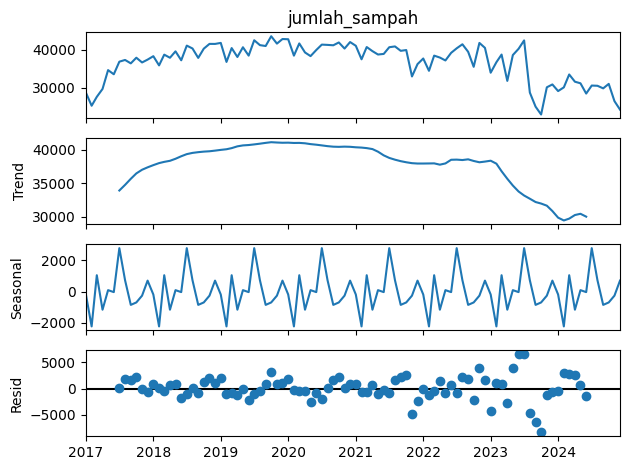

In [ ]:
# @title
decomp = seasonal_decompose(ts, model='additive', period=12)

decomp.plot()
plt.show()

Hasil Temuan
```
- Komponen tren naik sampai sekitar 2019–2020.
- Setelah itu, tren mulai menurun hingga 2024.
- Pola musiman terlihat berulang setiap tahun.
- Namun pola musiman tidak terlalu dominan.
- Residual menunjukkan fluktuasi acak.
- Ada beberapa lonjakan residual, terutama sekitar 2023–2024.

##**5. Train-Test Split**
```
Data dibagi menjadi data train dan test agar model bisa dilatih menggunakan data historis, lalu diuji pada 12 bulan terakhir.

In [ ]:
# @title
train = ts.iloc[:-12]
test = ts.iloc[-12:]

print("Jumlah data train:", len(train))
print("Jumlah data test:", len(test))

Jumlah data train: 84
Jumlah data test: 12


In [ ]:
# @title
print("Periode train:")
print(train.index.min(), "sampai", train.index.max())

Periode train:
2017-01-01 00:00:00 sampai 2023-12-01 00:00:00


In [ ]:
# @title
print("Periode test:")
print(test.index.min(), "sampai", test.index.max())

Periode test:
2024-01-01 00:00:00 sampai 2024-12-01 00:00:00


In [ ]:
# @title
display(train.tail())
display(test)

,jumlah_sampah
tanggal,
2023-08-01,28713.748
2023-09-01,24989.524
2023-10-01,22919.400
2023-11-01,30103.192
2023-12-01,30854.320


,jumlah_sampah
tanggal,
2024-01-01,29105.020
2024-02-01,30086.056
2024-03-01,33486.600
2024-04-01,31576.412
2024-05-01,31160.864
2024-06-01,28447.664
2024-07-01,30563.960
2024-08-01,30503.984
2024-09-01,29819.496


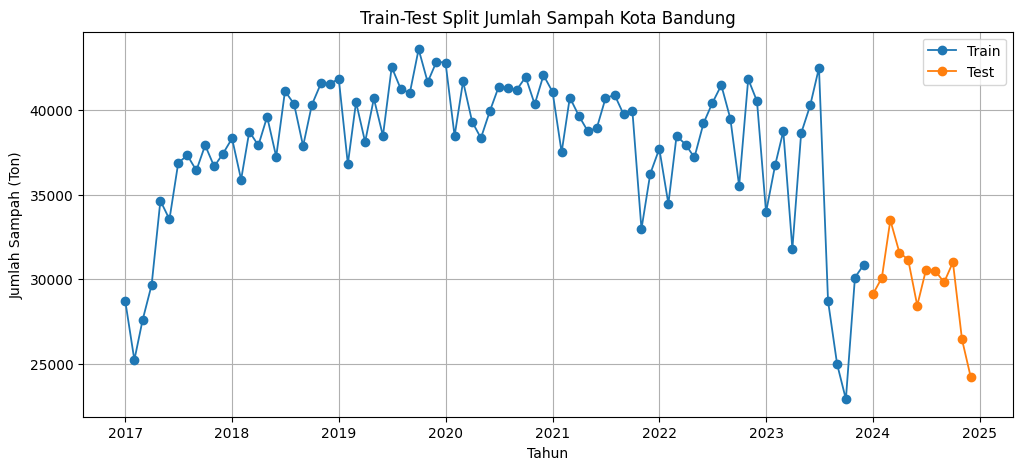

In [ ]:
# @title
plt.figure(figsize=(12,5))
plt.plot(train, marker='o', linewidth=1.3, label='Train')
plt.plot(test, marker='o', linewidth=1.3, label='Test')

plt.title('Train-Test Split Jumlah Sampah Kota Bandung')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Sampah (Ton)')
plt.legend()
plt.grid(True)
plt.show()

Hasil Temuan
```
- Data train berjumlah 84 observasi.
- Data test berjumlah 12 observasi.
- Periode train: Januari 2017 sampai Desember 2023.
- Periode test: Januari 2024 sampai Desember 2024.
- Data test dipakai untuk menguji kemampuan model memprediksi 12 bulan terakhir.
- Pada data test, jumlah sampah cenderung lebih rendah dibanding sebagian besar data train.

##**6. Uji Stasioneritas**
```
Uji stasioneritas dilakukan untuk melihat apakah data train sudah memiliki pola yang stabil sebelum digunakan dalam pemodelan
ARIMA.

###6.1 ADF Test pada Data Train

In [ ]:
# @title
result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -3.8006225366963258
p-value: 0.002900952047062443
Critical Values:
1%: -3.5117123057187376
5%: -2.8970475206326833
10%: -2.5857126912469153


###6.2 Interpretasi Hasil Uji Stasioneritas
```
- ADF Statistic = -3.8006.
- p-value = 0.0029.
- Nilai p-value < 0.05.
- Artinya data train stasioner secara statistik.
- Namun secara visual data masih menunjukkan perubahan pola.
- Oleh karena itu, differencing tetap dipertimbangkan pada tahap berikutnya.

##**7. Differencing**
```
Differencing dilakukan untuk melihat perubahan nilai antar bulan dan membantu membuat pola data lebih stabil sebelum pemodelan
ARIMA.

###7.1 First Differencing

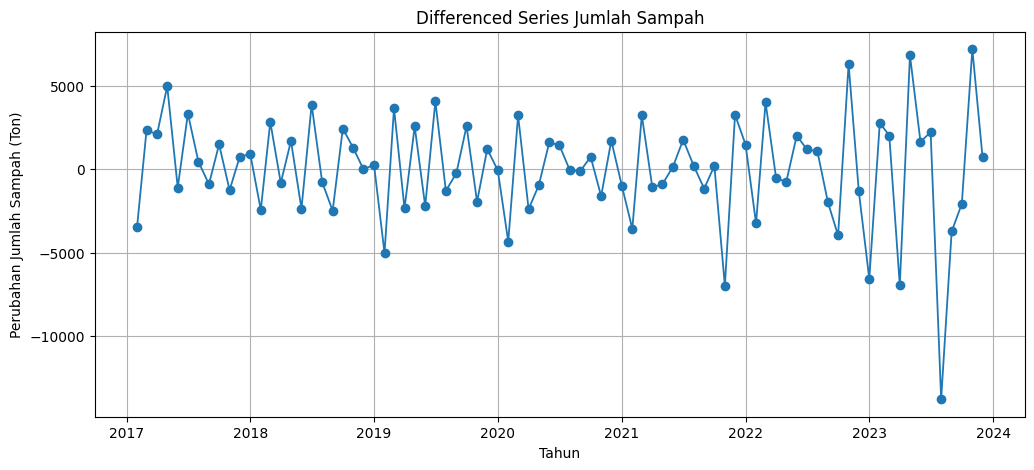

In [ ]:
# @title
ts_diff = train.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(ts_diff, marker='o', linewidth=1.3)

plt.title('Differenced Series Jumlah Sampah')
plt.xlabel('Tahun')
plt.ylabel('Perubahan Jumlah Sampah (Ton)')
plt.grid(True)
plt.show()

Hasil Temuan
```
- Data berubah menjadi selisih jumlah sampah antar bulan.
- Nilai perubahan sudah bergerak di sekitar angka 0.
- Masih terlihat fluktuasi yang cukup besar.
- Ada penurunan ekstrem sekitar akhir 2023.

###7.2 ADF Test Setelah Differencing

In [ ]:
# @title
result_diff = adfuller(ts_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
print("Critical Values:")
for key, value in result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.7167336112630303
p-value: 0.4225120927595822
Critical Values:
1%: -3.526004646825607
5%: -2.9032002348069774
10%: -2.5889948363419957


Hasil Temuan
```
- ADF Statistic = -1.7167.
- p-value = 0.4225.
- Nilai p-value > 0.05.
- Artinya data hasil differencing belum stasioner secara statistik.
- Namun differencing tetap berguna untuk melihat pola perubahan antar bulan.
- Pemilihan nilai `d` tetap akan divalidasi lagi melalui AIC pada tahap pemodelan ARIMA.

###7.3 ACF dan PACF
```
ACF dan PACF digunakan untuk melihat hubungan data dengan nilai lag sebelumnya. Grafik ini membantu menentukan kandidat awal
parameter AR dan MA pada model ARIMA.

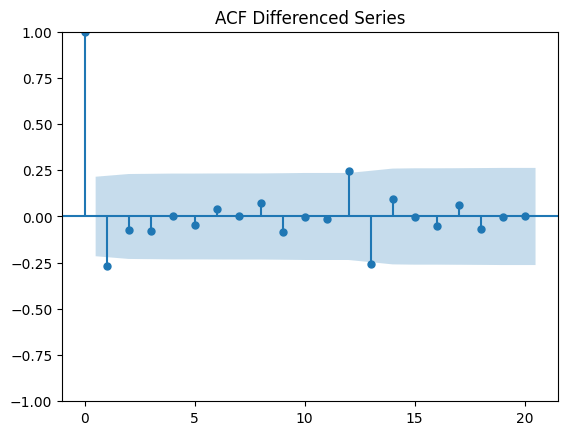

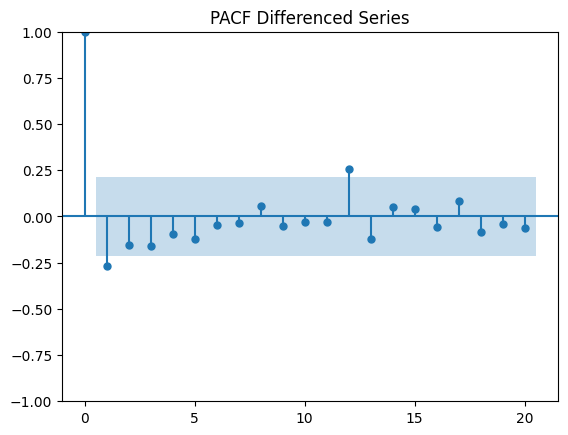

In [ ]:
# @title
plot_acf(ts_diff, lags=20)
plt.title('ACF Differenced Series')
plt.show()

plot_pacf(ts_diff, lags=20, method='ywm')
plt.title('PACF Differenced Series')
plt.show()

Hasil Temuan
```
- Pada grafik ACF, terlihat spike cukup jelas pada lag 1.
- Setelah lag 1, sebagian besar nilai berada dalam batas confidence interval.
- Pada grafik PACF, spike juga terlihat pada lag 1.
- Pola ACF dan PACF tidak menunjukkan hubungan lag yang panjang.
- Kandidat awal model yang dapat dicoba adalah ARIMA dengan parameter kecil,
  seperti ARIMA(1,1,1), ARIMA(0,1,1), atau ARIMA(1,1,0).
- Pemilihan model akhir tetap dilakukan berdasarkan nilai AIC.

##**8. Baseline Forecasting**
```
Baseline forecasting dibuat sebagai pembanding sederhana sebelum menggunakan model ARIMA dan SARIMA.

In [ ]:
# @title
# Naive Forecast: prediksi semua bulan test = nilai terakhir data train
naive_forecast = pd.Series(
    [train.iloc[-1]] * len(test),
    index=test.index
)

# Seasonal Naive Forecast: prediksi 2024 = pola 12 bulan terakhir dari train
seasonal_naive_forecast = train.iloc[-12:].copy()
seasonal_naive_forecast.index = test.index

# Fungsi evaluasi
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    return mae, rmse, mape, r2

# Evaluasi baseline
naive_eval = evaluate_forecast(test, naive_forecast)
seasonal_naive_eval = evaluate_forecast(test, seasonal_naive_forecast)

baseline_results = pd.DataFrame({
    'Model': ['Naive Forecast', 'Seasonal Naive Forecast'],
    'MAE': [naive_eval[0], seasonal_naive_eval[0]],
    'RMSE': [naive_eval[1], seasonal_naive_eval[1]],
    'MAPE': [naive_eval[2], seasonal_naive_eval[2]],
    'R2': [naive_eval[3], seasonal_naive_eval[3]]
})

display(baseline_results)

,Model,MAE,RMSE,MAPE,R2
0,Naive Forecast,1787.181667,2608.714931,6.519679,-0.242227
1,Seasonal Naive Forecast,6094.109000,6961.648048,20.738526,-7.846506


```
- Naive Forecast
  - MAE: 1787.18
  - RMSE: 2608.71
  - MAPE: 6.52%
  - R²: -0.24
- Seasonal Naive Forecast
  - MAE: 6094.11
  - RMSE: 6961.65
  - MAPE: 20.74%
  - R²: -7.85

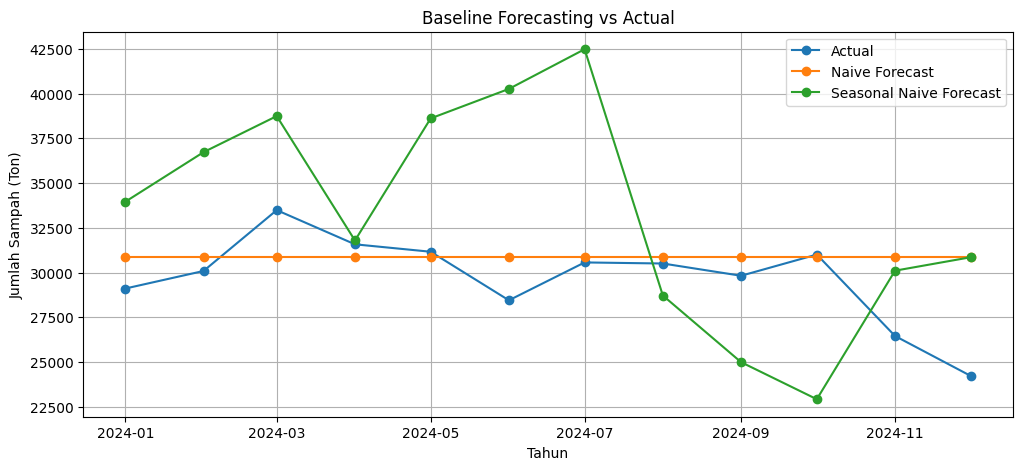

In [ ]:
# @title
# Visualisasi Baseline Forecasting

plt.figure(figsize=(12,5))
plt.plot(test, marker='o', label='Actual')
plt.plot(naive_forecast, marker='o', label='Naive Forecast')
plt.plot(seasonal_naive_forecast, marker='o', label='Seasonal Naive Forecast')

plt.title('Baseline Forecasting vs Actual')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Sampah (Ton)')
plt.legend()
plt.grid(True)
plt.show()

Hasil Temuan
```
- Naive Forecast menghasilkan error lebih kecil dibanding Seasonal Naive Forecast.
- Nilai MAPE Naive Forecast sebesar 6.52%, sedangkan Seasonal Naive Forecast sebesar 20.74%.
- Seasonal Naive Forecast kurang sesuai karena pola tahun sebelumnya tidak mirip dengan data aktual tahun 2024.
- Nilai R² pada kedua baseline masih negatif.
- Baseline ini digunakan sebagai pembanding awal sebelum model ARIMA dan SARIMA.

##**9. Pemodelan ARIMA**
```
Model ARIMA digunakan untuk memprediksi jumlah sampah berdasarkan pola historis pada data train.

###9.1 Model Awal ARIMA
```
Model awal ARIMA dicoba berdasarkan hasil ACF dan PACF sebelumnya, yaitu dengan parameter kecil sebagai percobaan awal.

In [ ]:
# @title
model_awal = ARIMA(train, order=(1,1,1))
model_awal_fit = model_awal.fit()

print(model_awal_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          jumlah_sampah   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -784.328
Date:                Wed, 13 May 2026   AIC                           1574.657
Time:                        02:53:04   BIC                           1581.913
Sample:                    01-01-2017   HQIC                          1577.572
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0385      0.316      0.122      0.903      -0.580       0.657
ma.L1         -0.2688      0.305     -0.882      0.378      -0.866       0.329
sigma2      8.874e+06    9.1e+05      9.749      0.0

###9.2 Pemilihan Parameter ARIMA Berdasarkan AIC

In [ ]:
# @title
p = range(0, 3)
d = range(0, 3)
q = range(0, 3)

pdq = list(itertools.product(p, d, q))

results = []

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        results.append({
            'order': order,
            'AIC': model_fit.aic
        })
    except:
        continue

arima_results = pd.DataFrame(results)
arima_results = arima_results.sort_values('AIC').reset_index(drop=True)

display(arima_results.head(10))

best_order = arima_results.loc[0, 'order']
best_aic = arima_results.loc[0, 'AIC']

print("Best ARIMA:", best_order)
print("Best AIC:", best_aic)

,order,AIC
0,"(0, 1, 1)",1572.596192
1,"(1, 1, 0)",1573.066876
2,"(2, 1, 0)",1574.566475
3,"(1, 1, 1)",1574.656847
4,"(0, 1, 2)",1574.705724
5,"(1, 1, 2)",1575.912930
6,"(2, 1, 1)",1576.637660
7,"(2, 1, 2)",1577.186014
8,"(1, 2, 2)",1577.249454
9,"(0, 2, 1)",1577.295907


Best ARIMA: (0, 1, 1)
Best AIC: 1572.596191517478


Hasil Temuan
```
- Model awal ARIMA(1,1,1) sudah dicoba sebagai percobaan awal.
- Nilai AIC model awal sebesar 1574.657.
- Setelah beberapa kombinasi dicoba, model terbaik berdasarkan AIC adalah ARIMA(0,1,1).
- Nilai AIC terkecil adalah 1572.596.
- Model ARIMA(0,1,1) digunakan untuk tahap diagnostic checking dan forecasting.

###9.3 Diagnostic Checking Residual ARIMA
```
Diagnostic checking dilakukan untuk melihat apakah residual model ARIMA masih memiliki pola tertentu atau sudah cukup acak.

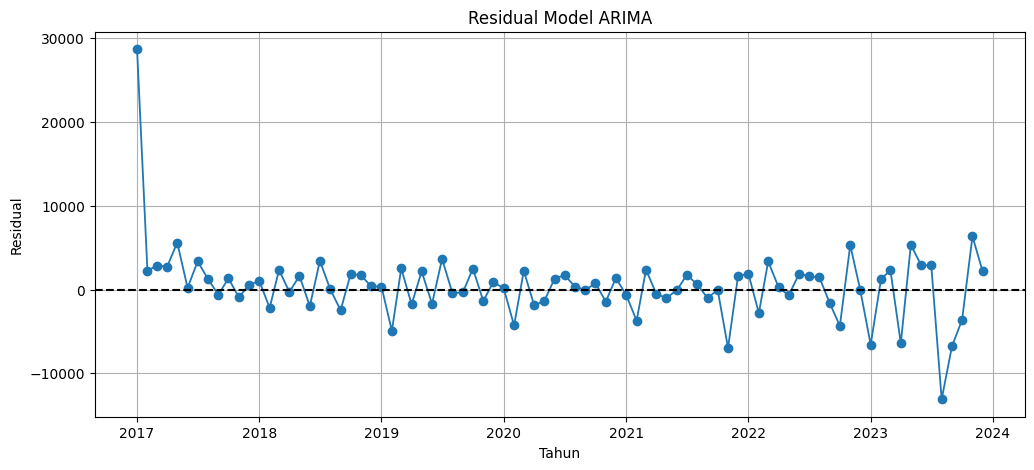

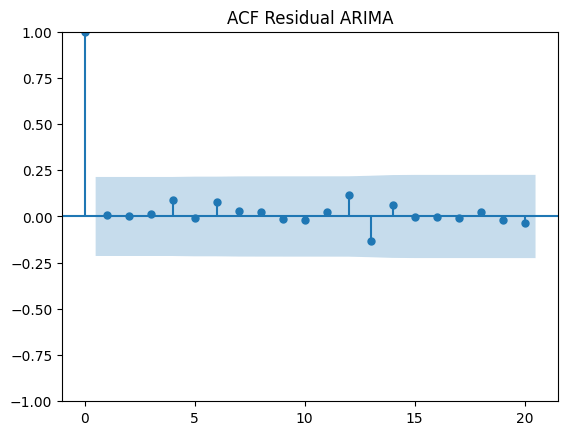

,lb_stat,lb_pvalue
10,1.519196,0.998874


In [ ]:
# @title
arima_model = ARIMA(train, order=best_order)
arima_fit = arima_model.fit()

# Mengambil residual
arima_residual = arima_fit.resid

# Plot residual
plt.figure(figsize=(12,5))
plt.plot(arima_residual, marker='o', linewidth=1.3)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Model ARIMA')
plt.xlabel('Tahun')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

# ACF residual
plot_acf(arima_residual, lags=20)
plt.title('ACF Residual ARIMA')
plt.show()

# Ljung-Box Test
ljungbox_result = acorr_ljungbox(arima_residual, lags=[10], return_df=True)
display(ljungbox_result)

Hasil Temuan
```
- Residual sebagian besar bergerak di sekitar angka 0.
- Masih terdapat beberapa residual yang cukup besar.
- Spike besar terlihat pada awal data dan sekitar 2023.
- Pada grafik ACF, hampir semua lag berada dalam batas confidence interval.
- Nilai p-value Ljung-Box = 0.9989.
- Karena p-value > 0.05, residual tidak menunjukkan autokorelasi yang signifikan.
- Secara umum, residual cukup acak, tetapi masih terdapat beberapa error besar.

###9.4 Forecasting ARIMA
```
Forecasting ARIMA dilakukan untuk memprediksi jumlah sampah pada data test, yaitu periode Januari sampai Desember 2024.

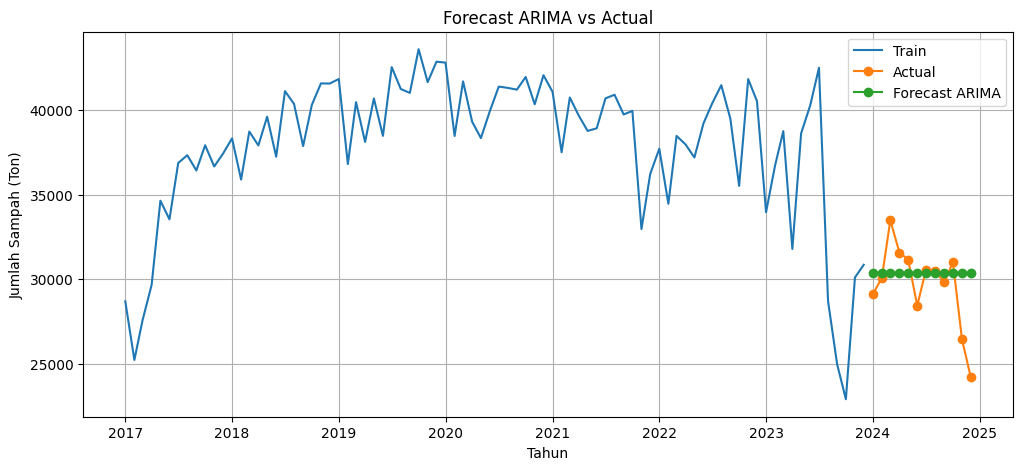

,Actual,Forecast_ARIMA
tanggal,,
2024-01-01,29105.020,30342.503049
2024-02-01,30086.056,30342.503049
2024-03-01,33486.600,30342.503049
2024-04-01,31576.412,30342.503049
2024-05-01,31160.864,30342.503049
2024-06-01,28447.664,30342.503049
2024-07-01,30563.960,30342.503049
2024-08-01,30503.984,30342.503049
2024-09-01,29819.496,30342.503049


In [ ]:
# @title
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

plt.figure(figsize=(12,5))
plt.plot(train, label='Train')
plt.plot(test, marker='o', label='Actual')
plt.plot(arima_forecast, marker='o', label='Forecast ARIMA')

plt.title('Forecast ARIMA vs Actual')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Sampah (Ton)')
plt.legend()
plt.grid(True)
plt.show()

# Menampilkan hasil forecast
forecast_arima_df = pd.DataFrame({
    'Actual': test,
    'Forecast_ARIMA': arima_forecast
})

display(forecast_arima_df)

Hasil Temuan
```
- Forecast ARIMA cenderung datar di sekitar 30.342 ton.
- Model belum mampu mengikuti naik-turun data aktual tahun 2024.
- Prediksi cukup dekat pada beberapa bulan tengah tahun.
- Selisih paling besar terlihat pada akhir 2024.
- Pola ini menunjukkan ARIMA lebih menangkap nilai rata-rata dibanding fluktuasi bulanan.

###9.5 Evaluasi ARIMA
```
Evaluasi ARIMA dilakukan untuk mengukur seberapa jauh hasil prediksi model dibandingkan dengan data aktual.

In [ ]:
# @title
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100
arima_r2 = r2_score(test, arima_forecast)

arima_eval = pd.DataFrame({
    'Model': ['ARIMA'],
    'MAE': [arima_mae],
    'RMSE': [arima_rmse],
    'MAPE': [arima_mape],
    'R2': [arima_r2]
})

display(arima_eval)

,Model,MAE,RMSE,MAPE,R2
0,ARIMA,1680.399,2426.554186,6.067581,-0.0748


```
- MAE = 1680.399.
- RMSE = 2426.554.
- MAPE = 6.067%.
- R² = -0.0748
```
```
- Nilai MAPE cukup kecil, yaitu sekitar 6%.
- Namun R² negatif menunjukkan model belum mampu menjelaskan variasi data test dengan baik.
- Dibanding Naive Forecast, ARIMA sedikit lebih baik karena nilai MAE, RMSE, dan MAPE lebih kecil.

##**10. Pemodelan SARIMA**
```
SARIMA digunakan untuk mencoba menangkap pola musiman bulanan pada data jumlah sampah.

###10.1 Pemilihan Parameter SARIMA Berdasarkan AIC
```
Pemilihan parameter SARIMA dilakukan dengan mencoba kombinasi parameter non-musiman dan musiman. Model dengan nilai AIC paling
kecil dipilih sebagai model terbaik.

In [ ]:
# @title
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

P = D = Q = range(0, 2)
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in itertools.product(P, D, Q)]

sarima_results = []

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            model_fit = model.fit(disp=False)

            sarima_results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'AIC': model_fit.aic
            })
        except:
            continue

sarima_results_df = pd.DataFrame(sarima_results)
sarima_results_df = sarima_results_df.sort_values('AIC').reset_index(drop=True)

display(sarima_results_df.head(10))

best_sarima_order = sarima_results_df.loc[0, 'order']
best_sarima_seasonal_order = sarima_results_df.loc[0, 'seasonal_order']
best_sarima_aic = sarima_results_df.loc[0, 'AIC']

print("Best SARIMA Order:", best_sarima_order)
print("Best SARIMA Seasonal Order:", best_sarima_seasonal_order)
print("Best AIC:", best_sarima_aic)

,order,seasonal_order,AIC
0,"(1, 2, 2)","(0, 1, 1, 12)",1056.215245
1,"(2, 2, 2)","(0, 1, 1, 12)",1057.711174
2,"(2, 2, 2)","(1, 1, 1, 12)",1061.743756
3,"(0, 2, 2)","(0, 1, 1, 12)",1062.739953
4,"(0, 2, 2)","(1, 1, 1, 12)",1062.779819
5,"(0, 1, 2)","(0, 1, 1, 12)",1072.752205
6,"(0, 1, 2)","(1, 1, 1, 12)",1074.365770
7,"(1, 2, 2)","(1, 1, 1, 12)",1074.539984
8,"(1, 1, 2)","(0, 1, 1, 12)",1074.621305
9,"(1, 1, 2)","(1, 1, 1, 12)",1076.220609


Best SARIMA Order: (1, 2, 2)
Best SARIMA Seasonal Order: (0, 1, 1, 12)
Best AIC: 1056.2152448766776


Hasil Temuan
```
- Model terbaik berdasarkan AIC adalah SARIMA(1,2,2)(0,1,1,12).
- Nilai AIC terkecil adalah 1056.215.
- Model ini memiliki komponen musiman dengan periode 12 bulan.
- Model terbaik berdasarkan AIC akan digunakan untuk diagnostic checking dan forecasting.

###10.2 Diagnostic Checking Residual SARIMA
```
Diagnostic checking dilakukan untuk melihat apakah residual SARIMA masih memiliki pola atau sudah cukup acak.

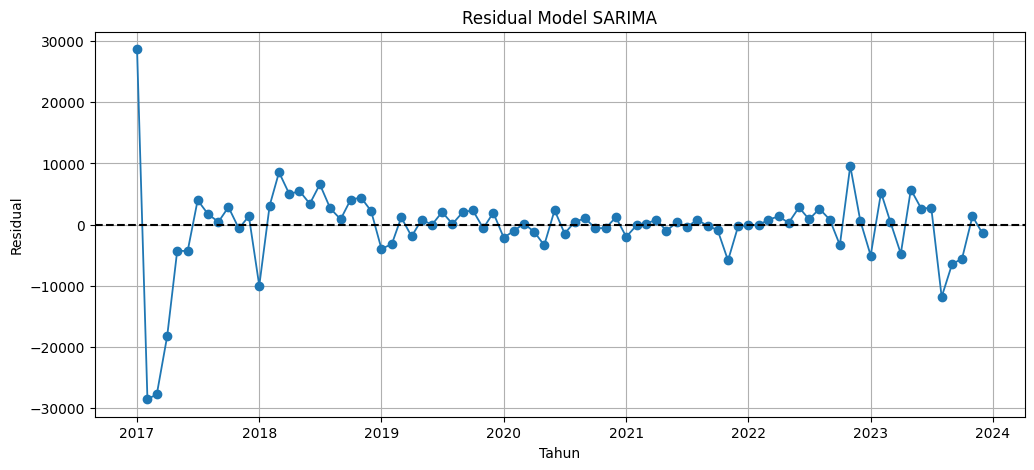

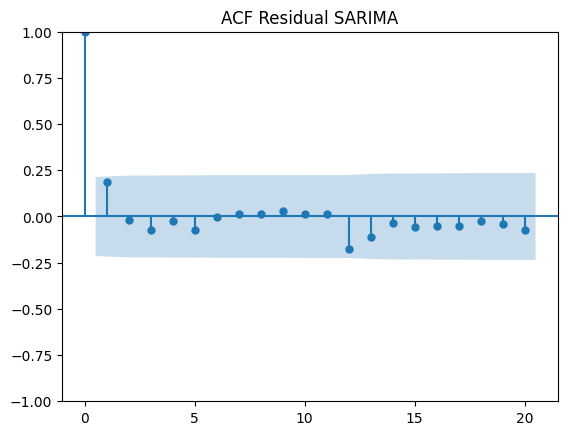

,lb_stat,lb_pvalue
10,4.321826,0.931663


In [ ]:
# @title
# Membuat model SARIMA terbaik
sarima_model = SARIMAX(
    train,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

# Mengambil residual
sarima_residual = sarima_fit.resid

# Plot residual
plt.figure(figsize=(12,5))
plt.plot(sarima_residual, marker='o', linewidth=1.3)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Model SARIMA')
plt.xlabel('Tahun')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

# ACF residual
plot_acf(sarima_residual, lags=20)
plt.title('ACF Residual SARIMA')
plt.show()

# Ljung-Box Test
ljungbox_sarima = acorr_ljungbox(sarima_residual, lags=[10], return_df=True)
display(ljungbox_sarima)

```
- Residual SARIMA sebagian besar bergerak di sekitar angka 0.
- Masih terdapat residual besar pada awal periode.
- Beberapa residual besar juga terlihat sekitar 2023.
- Pada grafik ACF, sebagian besar lag berada dalam batas confidence interval.
- Nilai p-value Ljung-Box = 0.9317.
- Karena p-value > 0.05, residual tidak menunjukkan autokorelasi yang signifikan.
- Secara umum, residual SARIMA cukup acak.

###10.3 Forecasting SARIMA
```
Forecasting SARIMA dilakukan untuk memprediksi jumlah sampah tahun 2024 dengan mempertimbangkan pola musiman bulanan.

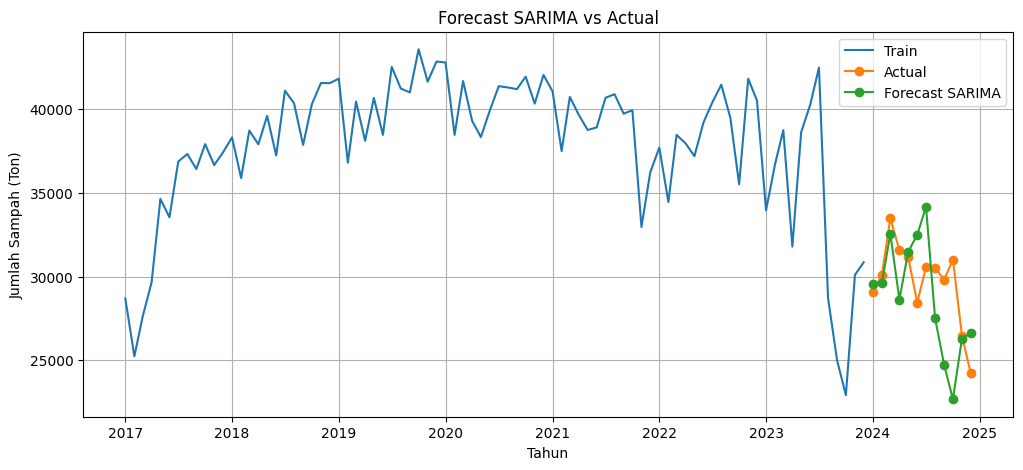

,Actual,Forecast_SARIMA
tanggal,,
2024-01-01,29105.020,29571.598249
2024-02-01,30086.056,29619.222733
2024-03-01,33486.600,32552.376949
2024-04-01,31576.412,28624.277700
2024-05-01,31160.864,31475.105021
2024-06-01,28447.664,32502.178804
2024-07-01,30563.960,34154.353864
2024-08-01,30503.984,27518.784877
2024-09-01,29819.496,24725.816146


In [ ]:
# @title
sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_forecast.index = test.index

plt.figure(figsize=(12,5))
plt.plot(train, label='Train')
plt.plot(test, marker='o', label='Actual')
plt.plot(sarima_forecast, marker='o', label='Forecast SARIMA')

plt.title('Forecast SARIMA vs Actual')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Sampah (Ton)')
plt.legend()
plt.grid(True)
plt.show()

# Menampilkan hasil forecast
forecast_sarima_df = pd.DataFrame({
    'Actual': test,
    'Forecast_SARIMA': sarima_forecast
})

display(forecast_sarima_df)

Hasil Temuan
```
- Forecast SARIMA terlihat lebih naik-turun dibanding ARIMA.
- Model SARIMA mencoba mengikuti pola musiman bulanan.
- Beberapa prediksi cukup dekat dengan data aktual.
- Namun masih ada selisih besar pada beberapa bulan.
- Selisih cukup besar terlihat sekitar Juni sampai Oktober 2024.
- Secara visual, SARIMA lebih dinamis dibanding ARIMA, tetapi tetap perlu dicek dengan metrik evaluasi.

###10.4 Evaluasi SARIMA
```
Evaluasi SARIMA dilakukan untuk melihat seberapa baik prediksi SARIMA dibandingkan dengan data aktual.

In [ ]:
# @title
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100
sarima_r2 = r2_score(test, sarima_forecast)

sarima_eval = pd.DataFrame({
    'Model': ['SARIMA'],
    'MAE': [sarima_mae],
    'RMSE': [sarima_rmse],
    'MAPE': [sarima_mape],
    'R2': [sarima_r2]
})

display(sarima_eval)

,Model,MAE,RMSE,MAPE,R2
0,SARIMA,2644.675702,3529.040846,8.875332,-1.273322


```
- MAE = 2644.676.
- RMSE = 3529.041.
- MAPE = 8.875%.
- R² = -1.2733.
```
```
- Nilai MAPE masih di bawah 10%, tetapi lebih besar dibanding ARIMA.
- Nilai R² negatif menunjukkan SARIMA belum mampu menjelaskan variasi data test dengan baik.
- Secara metrik, SARIMA belum lebih baik dari ARIMA.

##**11. Perbandingan Model**
```
Perbandingan model dilakukan untuk melihat model mana yang menghasilkan error paling kecil antara baseline, ARIMA, dan SARIMA.

###11.1 Perbandingan Baseline, ARIMA, dan SARIMA
```
Tabel ini dibuat untuk membandingkan hasil evaluasi dari semua model, yaitu baseline, ARIMA, dan SARIMA. Dari tabel ini dapat
dilihat model mana yang memiliki error paling kecil.

In [ ]:
# @title
comparison_results = pd.concat([
    baseline_results,
    arima_eval,
    sarima_eval
], ignore_index=True)

display(comparison_results)

,Model,MAE,RMSE,MAPE,R2
0,Naive Forecast,1787.181667,2608.714931,6.519679,-0.242227
1,Seasonal Naive Forecast,6094.109000,6961.648048,20.738526,-7.846506
2,ARIMA,1680.399000,2426.554186,6.067581,-0.074800
3,SARIMA,2644.675702,3529.040846,8.875332,-1.273322


Hasil Temuan
```
- ARIMA memiliki nilai MAE, RMSE, dan MAPE paling kecil.
- MAPE ARIMA = 6.067%, paling rendah dibanding model lain.
- Naive Forecast berada di urutan kedua dengan MAPE = 6.520%.
- SARIMA memiliki MAPE = 8.875%, lebih besar dari ARIMA.
- Seasonal Naive Forecast memiliki error paling besar.
- Semua model memiliki nilai R² negatif.
- Berdasarkan metrik evaluasi, ARIMA menjadi model terbaik.

###11.2 Perbandingan Visual Forecast vs Actual
```
Visualisasi ini dibuat untuk melihat secara langsung seberapa dekat garis prediksi setiap model dengan data aktual tahun 2024.

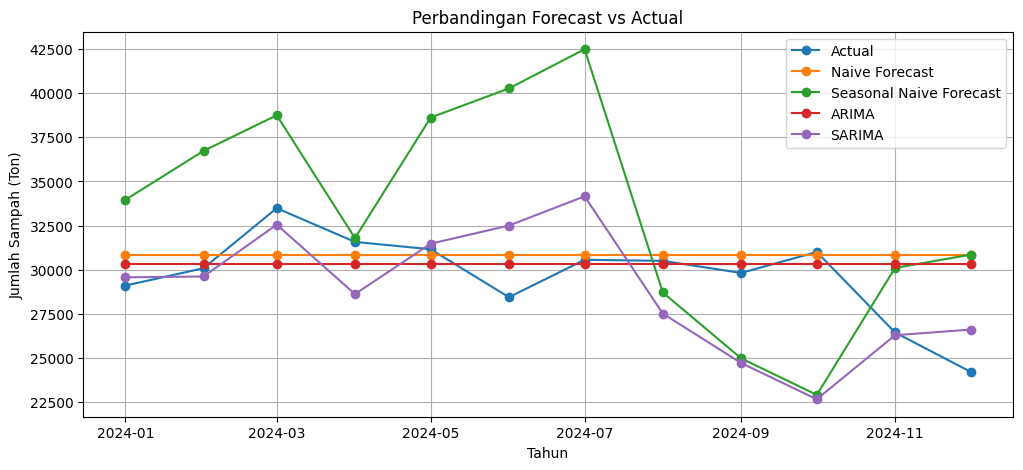

In [ ]:
# @title
plt.figure(figsize=(12,5))
plt.plot(test, marker='o', label='Actual')
plt.plot(naive_forecast, marker='o', label='Naive Forecast')
plt.plot(seasonal_naive_forecast, marker='o', label='Seasonal Naive Forecast')
plt.plot(arima_forecast, marker='o', label='ARIMA')
plt.plot(sarima_forecast, marker='o', label='SARIMA')

plt.title('Perbandingan Forecast vs Actual')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Sampah (Ton)')
plt.legend()
plt.grid(True)
plt.show()

Hasil Temuan
```
- ARIMA menghasilkan prediksi yang cenderung datar.
- Naive Forecast juga terlihat datar karena hanya memakai nilai terakhir data train.
- SARIMA lebih dinamis dan mengikuti naik-turun data.
- Seasonal Naive Forecast terlalu tinggi pada awal tahun dan turun tajam setelah pertengahan tahun.
- Secara visual, SARIMA terlihat lebih mengikuti pola naik-turun.
- Namun secara error, ARIMA tetap lebih baik.

###11.3 Perbandingan Metrik Evaluasi
```
Grafik MAPE dibuat untuk melihat perbedaan error persentase antar model dengan lebih mudah.

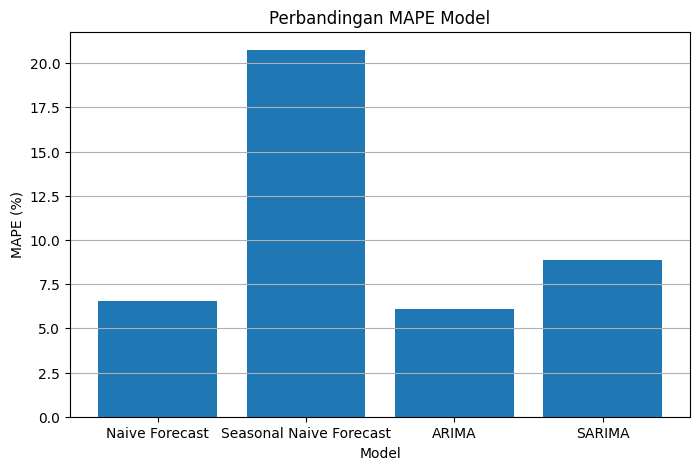

In [ ]:
# @title
plt.figure(figsize=(8,5))
plt.bar(comparison_results['Model'], comparison_results['MAPE'])

plt.title('Perbandingan MAPE Model')
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.grid(axis='y')
plt.show()

Hasil Temuan
```
- ARIMA memiliki MAPE paling rendah.
- Naive Forecast memiliki MAPE sedikit lebih tinggi dari ARIMA.
- SARIMA memiliki MAPE lebih besar dibanding ARIMA dan Naive Forecast.
- Seasonal Naive Forecast memiliki MAPE paling tinggi.
- Semakin kecil MAPE, semakin baik hasil prediksi model.
- Berdasarkan MAPE, model terbaik adalah ARIMA.

##**12. Pembahasan Hasil**
```
Merangkum temuan dari EDA, baseline, ARIMA, SARIMA, dan perbandingan model.

- Data jumlah sampah tidak sepenuhnya stabil dari tahun ke tahun.
- Pola naik terlihat sampai sekitar 2020, lalu mulai menurun setelahnya.
- Penurunan tajam pada 2023–2024 membuat pola data lebih sulit diprediksi.
- ARIMA menghasilkan prediksi yang cenderung datar karena model lebih menangkap pola rata-rata.
- SARIMA terlihat lebih dinamis karena mempertimbangkan pola musiman.
- Namun SARIMA belum lebih baik secara metrik karena error-nya masih lebih besar.
- Seasonal Naive Forecast kurang sesuai karena pola tahun sebelumnya tidak mirip dengan tahun 2024.
- Nilai R² negatif pada semua model menunjukkan bahwa variasi data test belum dapat dijelaskan dengan baik.
- Jadi, meskipun ARIMA menjadi model terbaik, model ini masih memiliki keterbatasan dalam menangkap perubahan tajam.

##**13. Kesimpulan**
```
- Model terbaik berdasarkan MAE, RMSE, dan MAPE adalah ARIMA(0,1,1).
- ARIMA memperoleh MAPE sebesar 6.067%.
- ARIMA sedikit lebih baik dibanding Naive Forecast.
- SARIMA lebih dinamis secara visual, tetapi error-nya lebih besar.
- Semua model memiliki R² negatif.
- Secara umum, model time series sederhana belum sepenuhnya mampu menangkap perubahan tajam pada data tahun 2024.